# Experimental: pressure-to-DHZ prediction and BCHH array response

This standalone experiment leaves production notebooks 060 and 070 unchanged. It compares a single clean pressure sensor (DD2) with the geometry-aligned arithmetic-mean DD1–DD3 pressure beam, estimates a **complex** pressure-to-vertical-velocity transfer, tests predictions on held-out time blocks, and calculates the spatial response of the three-element infrasound array.

The primary reported quantity is the held-out fraction of DHZ variance predicted by pressure. The remaining variance contains direct seismic energy, other seismic/noise sources, and model error; this analysis cannot separate those terms by itself. Predicted and residual powers can be shown as a conditional ratio, but must not be called a measured energy partition without independent validation of the transfer model.

Before fitting, DHZ is advanced by the SLC-40 path-time difference between DD2 and the seismometer, using the surveyed source-to-sensor distances and 351 m/s. This removes the known source-direction travel-time offset; the transfer phase is still estimated and can retain the local air-to-ground coupling phase. The optional quadrature model uses the Hilbert transform of pressure as the predictor for a nominal 90-degree pressure-to-DHZ relationship. The unconstrained complex transfer is the main comparator. It is fit using early windows from each of the four configured phases and the interphase tremor, then scored on later windows from each interval. Pre-event noise and the quiet gaps are held out as controls and never used to fit the transfer. Results remain sensitive to nonstationarity, pressure wind noise, calibration, and event overlap.

Run from the repository or its `notebooks/` directory. All scientific inputs and outputs are located through `modules.project_config`; this notebook writes only to an experimental subdirectory of `config.OUTPUT_DIR`.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime, read
from scipy.signal import butter, sosfiltfilt, hilbert, welch, csd


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "modules" / "project_config.py").is_file():
            return candidate
    raise FileNotFoundError("Cannot locate modules/project_config.py")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from modules import project_config as config
if Path(config.__file__).resolve() != PROJECT_ROOT / "modules" / "project_config.py":
    raise RuntimeError("Imported project_config from an unexpected location")

OUTDIR = config.OUTPUT_DIR / "155_experimental_pressure_dhz_array"
OUTDIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_CONFIG = json.loads((config.NB010_DIR / "analysis_configuration.json").read_text())
GEOMETRY = pd.read_csv(ANALYSIS_CONFIG["geometry_file"])
STREAM_PATH = Path(ANALYSIS_CONFIG["stream_file"]).expanduser()
if not STREAM_PATH.is_file():
    raise FileNotFoundError(STREAM_PATH)
print("Config:", config.__file__)
print("Analysis stream:", STREAM_PATH)
print("Output:", OUTDIR)


Config: /Users/thompsong/Developer/KSCRocketSeismology/08_falcon9_fireball_paper/modules/project_config.py
Analysis stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/bchh_corrected_analysis_window.pkl
Output: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/155_experimental_pressure_dhz_array


## Analysis choices

The default bands target the recurring local coupling bands from Notebook 070. The broader 1–30 Hz band is retained for an overview; interpretation should focus on bands with stable held-out coherence and transfer phase. Ten-second windows are long enough to resolve the lower band, but yield few independent windows in short intervals. The complete common record is retained, so the Phase I, tremor, Phases II–IV, pre-event baseline, interphase quiet gaps, and post-event background contribute their available windows. Treat interval metrics cautiously when counts are low.

DHZ is advanced by the known SLC-40 differential travel time to DD2 using the 351 m/s adopted propagation speed. The pressure beam shifts each sensor by its geometrical travel-time difference to DD2 using the array-alignment speed. This is a sensitivity comparison, not a new source-time estimate. The held-out blocks are chronological (first 70% within each event interval for training, last 30% for held-out scoring); inspect stationarity before treating the scores as generalizable.


In [2]:
# Sensitivity settings, editable for controlled experiments.
ARRAY_ALIGNMENT_SPEED_MPS = 352.0  # existing DD1-DD3 to DD2 array alignment
SLC40_PROPAGATION_SPEED_MPS = 351.0  # adopted source-to-BCHH airwave speed
SEGMENT_SECONDS = 10.0
TRAIN_FRACTION = 0.70
FREQUENCY_BANDS_HZ = [(3.5, 5.5), (12.0, 15.0), (19.0, 24.5)]
TRANSFER_BAND_HZ = (1.0, 30.0)
TIKHONOV_FRACTION = 0.05  # ridge term relative to median training pressure spectrum

# Source-time intervals from the shared config are shifted to DD2 arrivals
# using DD2's surveyed SLC-40 distance and the adopted 351 m/s speed.
reference_channel = str(ANALYSIS_CONFIG["infrasound_reference_channel"])
if reference_channel != "DD2":
    raise ValueError(f"Expected DD2 reference; config specifies {reference_channel}")
geometry_channels = GEOMETRY.loc[GEOMETRY.channel.isin(["DD1", "DD2", "DD3", "DHZ"])].set_index("channel")
if set(geometry_channels.index) != {"DD1", "DD2", "DD3", "DHZ"} or "distance_m" not in geometry_channels:
    raise ValueError("Geometry table must include SLC-40 distances for DD1/DD2/DD3/DHZ")
coords = geometry_channels.loc[["DD1", "DD2", "DD3"]]
ref_dist = float(geometry_channels.loc["DD2", "distance_m"])
dhz_dist = float(geometry_channels.loc["DHZ", "distance_m"])
DHZ_ADVANCE_S = (dhz_dist - ref_dist) / SLC40_PROPAGATION_SPEED_MPS
reference_travel_s = ref_dist / SLC40_PROPAGATION_SPEED_MPS

EVENT_INTERVALS = []
for label, start, end in config.OVERVIEW_PHASE_INTERVALS:
    EVENT_INTERVALS.append((str(label), UTCDateTime(start) + reference_travel_s,
                            UTCDateTime(end) + reference_travel_s))
EVENT_INTERVALS.append(("Interphase tremor", 
    UTCDateTime(config.OVERVIEW_PROLONGED_SIGNAL_INTERVAL[0]) + reference_travel_s,
    UTCDateTime(config.OVERVIEW_PROLONGED_SIGNAL_INTERVAL[1]) + reference_travel_s))
EVENT_INTERVALS.sort(key=lambda row: float(row[1]))
EVENT_LABELS = [row[0] for row in EVENT_INTERVALS]

stream = read(str(STREAM_PATH), format="PICKLE")
def one_trace(channel):
    found = stream.select(channel=channel)
    if len(found) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(found)}")
    return found[0]
pressure_channels = ["DD1", "DD2", "DD3"]
pressure_traces = {ch: one_trace(ch) for ch in pressure_channels}
dhz = one_trace("DHZ")
# Advancing DHZ by positive delta means aligned_DHZ(t) = raw_DHZ(t + delta).
# Restrict the common interval so this fractional-sample interpolation stays valid.
RECORD_START = max([t.stats.starttime for t in pressure_traces.values()] + [dhz.stats.starttime - DHZ_ADVANCE_S])
RECORD_END = min([t.stats.endtime for t in pressure_traces.values()] + [dhz.stats.endtime - DHZ_ADVANCE_S])
print(f"SLC-40 distance DD2: {ref_dist:.3f} m; DHZ: {dhz_dist:.3f} m")
print(f"DHZ advance to DD2 arrival time: {DHZ_ADVANCE_S:.6f} s ({DHZ_ADVANCE_S * 250:.2f} samples at 250 Hz)")
print("Configured event windows (shifted to DD2 arrival):")
for label,start,end in EVENT_INTERVALS:
    print(f"  {label}: {start} to {end} ({float(end-start):.1f} s)")
print("Usable common record after alignment:", RECORD_START, "to", RECORD_END)


SLC-40 distance DD2: 1408.338 m; DHZ: 1419.887 m
DHZ advance to DD2 arrival time: 0.032900 s (8.23 samples at 250 Hz)
Configured event windows (shifted to DD2 arrival):
  Phase I: 2016-09-01T13:07:15.925360Z to 2016-09-01T13:08:25.925360Z (70.0 s)
  Interphase tremor: 2016-09-01T13:08:52.012360Z to 2016-09-01T13:12:04.012360Z (192.0 s)
  Phase II: 2016-09-01T13:14:09.012360Z to 2016-09-01T13:15:59.012360Z (110.0 s)
  Phase III: 2016-09-01T13:19:06.012360Z to 2016-09-01T13:25:04.012360Z (358.0 s)
  Phase IV: 2016-09-01T13:29:43.012360Z to 2016-09-01T13:34:58.012360Z (315.0 s)
Usable common record after alignment: 2016-09-01T13:04:11.912000Z to 2016-09-01T13:37:11.879100Z


## Build labelled event and noise windows

The complete common record is partitioned into the four configured phases, the configured interphase tremor, pre-event noise, all quiet gaps, and post-event noise. Every complete non-overlapping 10-second window is retained. Pressure traces are aligned to DD2 using their surveyed differential travel times; DHZ is advanced by its SLC-40 path-time difference relative to DD2. Quiet intervals are held out from transfer fitting and used to characterize pressure and DHZ noise and false prediction. The pre-event interval provides the primary background estimate before the first modeled arrival.


In [3]:
fs = min([float(t.stats.sampling_rate) for t in pressure_traces.values()] + [float(dhz.stats.sampling_rate)])
dt = 1.0 / fs

def sample_trace(trace, epoch_grid):
    start = float(trace.stats.starttime.timestamp)
    epochs = start + np.arange(trace.stats.npts, dtype=float) / float(trace.stats.sampling_rate)
    return np.interp(epoch_grid, epochs, np.asarray(trace.data, dtype=float), left=np.nan, right=np.nan)

# Label all configured event/tremor windows and every intervening quiet interval.
# The pre-event interval is kept as a separate baseline-noise class.
labelled_intervals = []
cursor_time = RECORD_START
previous_event = None
for label, start, end in EVENT_INTERVALS:
    start = max(start, RECORD_START); end = min(end, RECORD_END)
    if end <= start:
        continue
    if cursor_time < start:
        quiet_label = "pre-event noise" if previous_event is None else f"quiet gap after {previous_event}"
        labelled_intervals.append((quiet_label, cursor_time, start, "quiet"))
    labelled_intervals.append((label, start, end, "event"))
    cursor_time = end
    previous_event = label
if cursor_time < RECORD_END:
    labelled_intervals.append(("post-event noise", cursor_time, RECORD_END, "quiet"))

all_p = {ch: [] for ch in pressure_channels}
all_times, all_v, all_segment_id = [], [], []
segment_labels, segment_kinds, segment_start_epochs = [], [], []
segment_samples = int(round(SEGMENT_SECONDS * fs))
for label, interval_start, interval_end, kind in labelled_intervals:
    cursor = interval_start
    while cursor + SEGMENT_SECONDS <= interval_end:
        relative = np.arange(segment_samples, dtype=float) * dt
        epochs = float(cursor.timestamp) + relative
        aligned = {}
        for ch, trace in pressure_traces.items():
            differential_delay = (float(coords.loc[ch, "distance_m"]) - ref_dist) / ARRAY_ALIGNMENT_SPEED_MPS
            aligned[ch] = sample_trace(trace, epochs + differential_delay)
        velocity = sample_trace(dhz, epochs + DHZ_ADVANCE_S)  # advance DHZ to DD2 SLC-40 arrival time
        matrix = np.vstack([aligned[ch] for ch in pressure_channels] + [velocity])
        if np.isfinite(matrix).all():
            for ch in pressure_channels:
                all_p[ch].append(aligned[ch])
            all_v.append(velocity)
            all_times.append(epochs)
            all_segment_id.append(len(segment_labels))
            segment_labels.append(label)
            segment_kinds.append(kind)
            segment_start_epochs.append(float(cursor.timestamp))
        cursor += SEGMENT_SECONDS

if len(segment_labels) < 20:
    raise ValueError(f"Only {len(segment_labels)} complete 10-s windows across the record; check channel coverage")
P = {ch: np.vstack(rows) for ch, rows in all_p.items()}
V = np.vstack(all_v)
EPOCHS = np.vstack(all_times)
SEGMENT_IDS = np.asarray(all_segment_id)
GROUP_LABELS = np.asarray(segment_labels, dtype=str)
GROUP_KINDS = np.asarray(segment_kinds, dtype=str)
SEGMENT_START_EPOCHS = np.asarray(segment_start_epochs, dtype=float)
P["beam"] = np.mean(np.stack([P[ch] for ch in pressure_channels]), axis=0)
segment_inventory = pd.DataFrame({
    "segment_index": np.arange(len(GROUP_LABELS)),
    "start_utc": [str(UTCDateTime(t)) for t in SEGMENT_START_EPOCHS],
    "class": GROUP_LABELS, "window_kind": GROUP_KINDS,
})
segment_inventory.to_csv(OUTDIR / "experimental_segment_inventory.csv", index=False)
counts = segment_inventory.groupby(["window_kind", "class"]).size().rename("complete_10s_windows").reset_index()
counts.to_csv(OUTDIR / "experimental_window_counts.csv", index=False)
display(counts)

# Within each event class, use the early 70% for transfer estimation and the
# later 30% as a chronological holdout. Quiet intervals are never used to fit H.
train_segments = np.zeros(len(GROUP_LABELS), dtype=bool)
test_masks = {}
for label in EVENT_LABELS:
    ids = np.flatnonzero((GROUP_LABELS == label) & (GROUP_KINDS == "event"))
    if len(ids) < 6:
        print(f"Skipping transfer evaluation for {label}: only {len(ids)} windows")
        continue
    ntrain = min(len(ids)-2, max(3, int(np.floor(len(ids)*TRAIN_FRACTION))))
    train_segments[ids[:ntrain]] = True
    test_masks[label] = np.isin(np.arange(len(GROUP_LABELS)), ids[ntrain:])
    print(f"{label}: {len(ids)} windows; train {ntrain}; held out {len(ids)-ntrain}")
if train_segments.sum() < 20:
    raise ValueError(f"Only {train_segments.sum()} event/tremor training windows; insufficient for pooled H1")
for label in sorted(set(GROUP_LABELS[GROUP_KINDS == "quiet"])):
    test_masks[label] = (GROUP_LABELS == label) & (GROUP_KINDS == "quiet")
print(f"Pooled event/tremor training windows: {train_segments.sum()}; quiet intervals excluded from fitting")


,window_kind,class,complete_10s_windows
0,event,Interphase tremor,19
1,event,Phase I,7
2,event,Phase II,11
3,event,Phase III,35
4,event,Phase IV,31
5,quiet,post-event noise,13
6,quiet,pre-event noise,18
7,quiet,quiet gap after Interphase tremor,12
8,quiet,quiet gap after Phase I,2
9,quiet,quiet gap after Phase II,18


Phase I: 7 windows; train 4; held out 3
Interphase tremor: 19 windows; train 13; held out 6
Phase II: 11 windows; train 7; held out 4
Phase III: 35 windows; train 24; held out 11
Phase IV: 31 windows; train 21; held out 10
Pooled event/tremor training windows: 69; quiet intervals excluded from fitting


## Estimate a pooled complex transfer and score each interval

Fit H1 using the early 70% of windows from each of the five event/tremor intervals after advancing DHZ to the DD2 arrival time by the known SLC-40 differential travel time. The fitted transfer phase is still free to capture coupling and instrument phase. Score the later windows from each interval separately. Pre-event noise and quiet gaps never enter the transfer fit; the same model predicts those intervals as negative/control checks. Also report interval counts and observed/predicted/residual power so event phases and quiet backgrounds are not conflated.


In [4]:
def detrend_rows(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(x.shape[1], dtype=float)
    out = np.empty_like(x)
    for i, row in enumerate(x):
        slope, intercept = np.polyfit(t, row, 1)
        out[i] = row - (slope * t + intercept)
    return out


def transfer_predict(pressure_segments, velocity_segments, train_mask, test_mask):
    p = detrend_rows(pressure_segments)
    v = detrend_rows(velocity_segments)
    nperseg = p.shape[1]
    f, spp = welch(p[train_mask], fs=fs, nperseg=nperseg, axis=1, scaling="density")
    _, spv = csd(p[train_mask], v[train_mask], fs=fs, nperseg=nperseg, axis=1, scaling="density")
    spp_mean = np.mean(spp, axis=0)
    spv_mean = np.mean(spv, axis=0)
    _, svv = welch(v[train_mask], fs=fs, nperseg=nperseg, axis=1, scaling="density")
    svv_mean = np.mean(svv, axis=0)
    floor = TIKHONOV_FRACTION * np.nanmedian(spp_mean[spp_mean > 0])
    H = spv_mean / np.maximum(spp_mean + floor, np.finfo(float).tiny)
    coherence = np.clip(np.abs(spv_mean)**2 / np.maximum(spp_mean * svv_mean, np.finfo(float).tiny), 0, 1)
    predictions, observed = [], []
    for p_row, v_row in zip(p[test_mask], v[test_mask]):
        pred = np.fft.irfft(H * np.fft.rfft(p_row), n=len(p_row))
        predictions.append(pred); observed.append(v_row)
    pred = np.vstack(predictions); obs = np.vstack(observed)
    sos = butter(4, TRANSFER_BAND_HZ, btype="bandpass", fs=fs, output="sos")
    obs_f = sosfiltfilt(sos, obs, axis=1)
    pred_f = sosfiltfilt(sos, pred, axis=1)
    residual = obs_f - pred_f
    total_ms = float(np.mean(obs_f**2)); predicted_ms = float(np.mean(pred_f**2)); residual_ms = float(np.mean(residual**2))
    metrics = {
        "heldout_window_count": int(test_mask.sum()),
        "heldout_correlation": float(np.corrcoef(obs_f.ravel(), pred_f.ravel())[0,1]),
        "heldout_variance_explained": 1.0 - residual_ms / total_ms if total_ms else np.nan,
        "observed_mean_square": total_ms,
        "predicted_mean_square": predicted_ms,
        "residual_mean_square": residual_ms,
        "conditional_predicted_to_residual_ratio": predicted_ms / residual_ms if residual_ms else np.inf,
        "conditional_predicted_fraction_of_observed_mean_square": predicted_ms / total_ms if total_ms else np.nan,
    }
    return f, H, coherence, obs_f, pred_f, residual, metrics

results = {}
transfer_rows = []
summary_rows = []
for name, pressure in P.items():
    for label, test_mask in test_masks.items():
        if not np.any(test_mask):
            continue
        f,H,coh,obs,pred,resid,metrics = transfer_predict(pressure,V,train_segments,test_mask)
        results[(name,label)] = (f,H,coh,obs,pred,resid,metrics)
        summary_rows.append({"input":name,"evaluation_interval":label,"window_kind":str(GROUP_KINDS[np.flatnonzero(test_mask)[0]]),**metrics})
    # Export the single pooled transfer estimated only from event/tremor training windows.
    f,H,coh,_,_,_,_ = transfer_predict(pressure,V,train_segments,~train_segments)
    for freq,h,c in zip(f,H,coh):
        if TRANSFER_BAND_HZ[0] <= freq <= TRANSFER_BAND_HZ[1]:
            transfer_rows.append({"input":name,"frequency_hz":freq,"H_real_mps_per_pa":h.real,
                "H_imag_mps_per_pa":h.imag,"H_magnitude_mps_per_pa":abs(h),
                "H_phase_deg":np.degrees(np.angle(h)),"training_coherence":c})

transfer_table=pd.DataFrame(transfer_rows)
transfer_table.to_csv(OUTDIR/"experimental_complex_transfer.csv",index=False)
summary=pd.DataFrame(summary_rows)
summary.to_csv(OUTDIR/"experimental_heldout_prediction_summary.csv",index=False)
display(summary)


,input,evaluation_interval,window_kind,heldout_window_count,heldout_correlation,heldout_variance_explained,observed_mean_square,predicted_mean_square,residual_mean_square,conditional_predicted_to_residual_ratio,conditional_predicted_fraction_of_observed_mean_square
0,DD1,Phase I,event,3,0.255107,-6.294902,1.207240e-10,9.309999e-10,8.806695e-10,1.057150,7.711807
1,DD1,Interphase tremor,event,6,0.037933,-29.250733,3.297837e-11,9.782575e-10,9.976198e-10,0.980591,29.663611
2,DD1,Phase II,event,4,0.159104,-17.786556,9.747121e-11,1.869554e-09,1.831148e-09,1.020973,19.180572
3,DD1,Phase III,event,11,0.050789,-52.266536,1.327079e-11,7.034301e-10,7.068890e-10,0.995107,53.005898
4,DD1,Phase IV,event,10,0.041730,-52.850035,3.167192e-11,1.693200e-09,1.705534e-09,0.992768,53.460589
5,DD1,post-event noise,quiet,13,0.011042,-584.130703,9.939625e-13,5.811342e-10,5.815980e-10,0.999203,584.664086
6,DD1,pre-event noise,quiet,18,-0.002517,-564.247908,1.408645e-12,7.946570e-10,7.962339e-10,0.998020,564.128466
7,DD1,quiet gap after Interphase tremor,quiet,12,-0.030906,-348.786657,3.911522e-12,1.359776e-09,1.368198e-09,0.993845,347.633590
8,DD1,quiet gap after Phase I,quiet,2,-0.090039,-57.502889,2.887557e-11,1.621492e-09,1.689304e-09,0.959858,56.154454
9,DD1,quiet gap after Phase II,quiet,18,-0.034969,-783.651542,2.366939e-12,1.850226e-09,1.857222e-09,0.996233,781.695829


## Compare a band-limited Hilbert quadrature model

Fit one real scale between the pressure Hilbert quadrature and DHZ using only event/tremor training windows. Score it separately on each held-out phase and each quiet interval. A good quadrature prediction is consistent with a simple 90-degree relationship, but does not by itself identify air-to-ground coupling or a Rayleigh wave.


In [5]:
quadrature_rows = []
for name, pressure in P.items():
    p0 = detrend_rows(pressure); v0 = detrend_rows(V)
    for low, high in FREQUENCY_BANDS_HZ:
        sos = butter(4, (low, high), btype="bandpass", fs=fs, output="sos")
        p = sosfiltfilt(sos, p0, axis=1); v = sosfiltfilt(sos, v0, axis=1)
        q = np.imag(hilbert(p, axis=1))
        qtr=q[train_segments].ravel();vtr=v[train_segments].ravel()
        scale=float(np.dot(qtr,vtr)/np.dot(qtr,qtr)) if np.dot(qtr,qtr)>0 else np.nan
        for label,test_mask in test_masks.items():
            qhat=scale*q[test_mask].ravel();vtest=v[test_mask].ravel();residual=vtest-qhat
            quadrature_rows.append({"input":name,"evaluation_interval":label,"band_low_hz":low,"band_high_hz":high,
                "heldout_window_count":int(test_mask.sum()),"quadrature_scale_mps_per_pa":scale,
                "heldout_correlation":float(np.corrcoef(vtest,qhat)[0,1]),
                "heldout_variance_explained":float(1-np.mean(residual**2)/np.mean(vtest**2)),
                "conditional_predicted_to_residual_mean_square":float(np.mean(qhat**2)/np.mean(residual**2))})
quadrature_summary=pd.DataFrame(quadrature_rows)
quadrature_summary.to_csv(OUTDIR/"experimental_hilbert_quadrature_comparison.csv",index=False)
display(quadrature_summary)


,input,evaluation_interval,band_low_hz,band_high_hz,heldout_window_count,quadrature_scale_mps_per_pa,heldout_correlation,heldout_variance_explained,conditional_predicted_to_residual_mean_square
0,DD1,Phase I,3.5,5.5,3,7.126155e-07,0.001892,-0.075196,0.070909
1,DD1,Interphase tremor,3.5,5.5,6,7.126155e-07,0.007094,-1.471833,0.602447
2,DD1,Phase II,3.5,5.5,4,7.126155e-07,-0.024438,-0.160366,0.122333
3,DD1,Phase III,3.5,5.5,11,7.126155e-07,0.010829,-4.410131,0.823612
4,DD1,Phase IV,3.5,5.5,10,7.126155e-07,0.013844,-14.798148,0.943468
...,...,...,...,...,...,...,...,...,...
127,beam,pre-event noise,19.0,24.5,18,1.709914e-06,-0.009272,-7.100231,0.870468
128,beam,quiet gap after Interphase tremor,19.0,24.5,12,1.709914e-06,-0.005749,-0.987402,0.491115
129,beam,quiet gap after Phase I,19.0,24.5,2,1.709914e-06,0.077908,-0.111575,0.159376
130,beam,quiet gap after Phase II,19.0,24.5,18,1.709914e-06,0.032162,-7.158738,0.898782


## Held-out waveforms by event phase

For each event/tremor class, plot the first held-out 10-second window: DHZ advanced to the DD2 arrival time, the DD2-based prediction, and the beam-based prediction. The full per-window counts and interval metrics are in the CSV outputs.


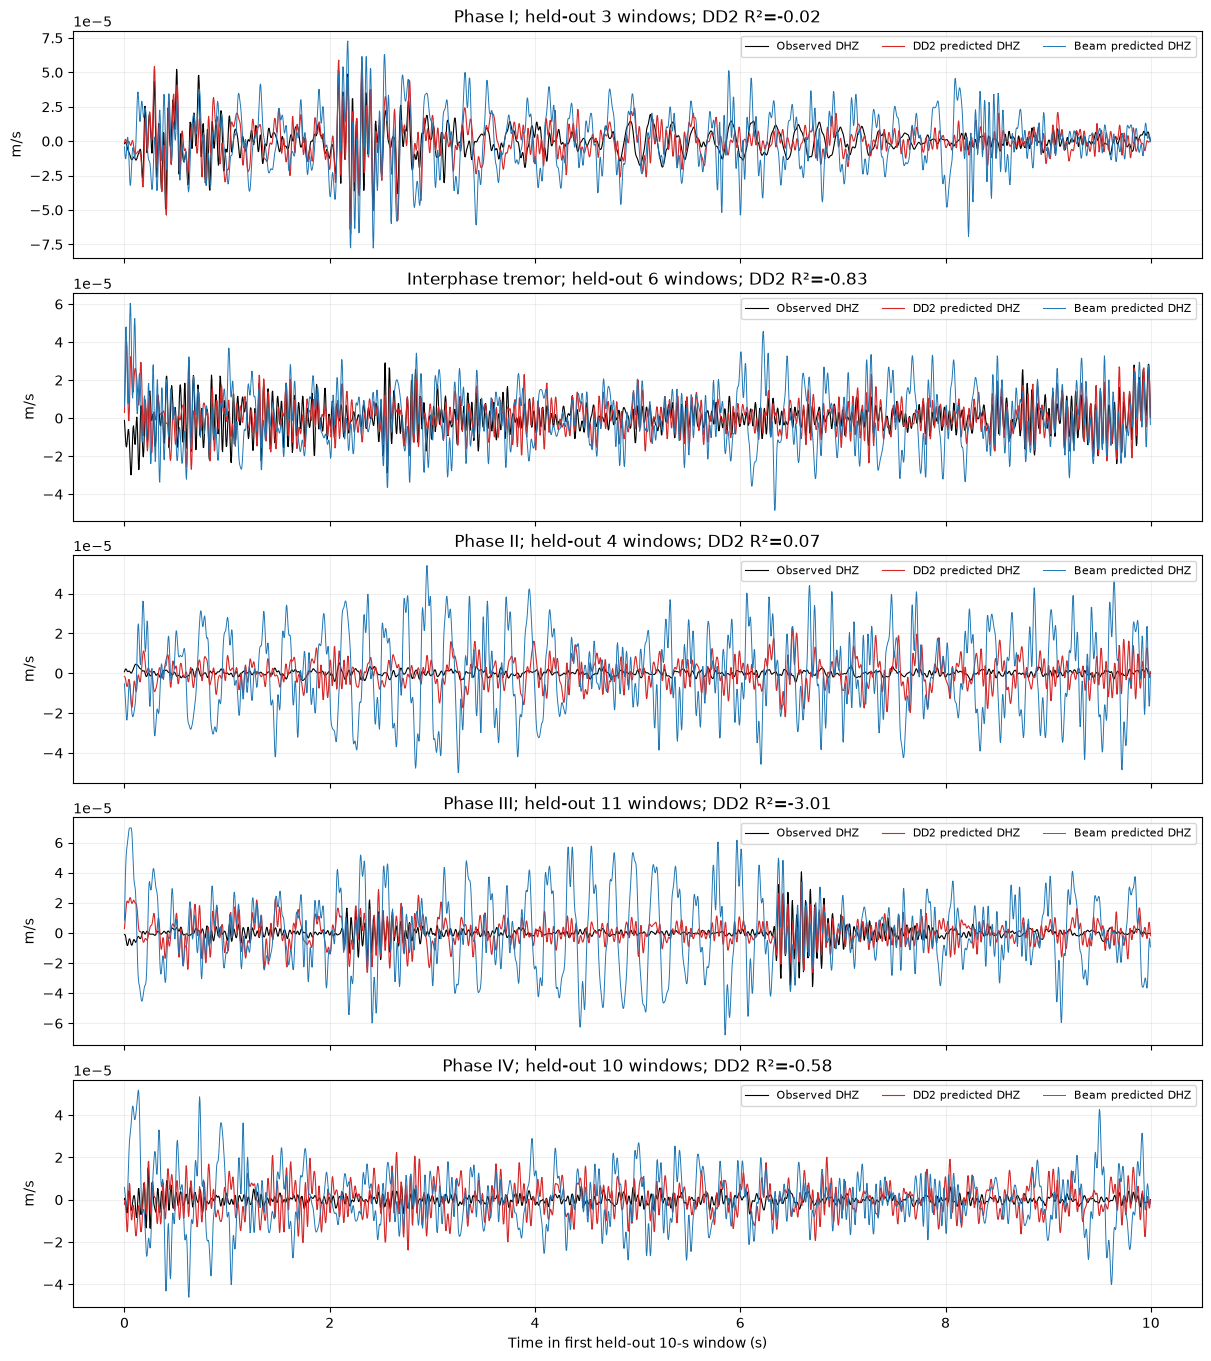

In [6]:
# Plot the held-out windows for the five event/tremor classes, comparing DD2 and beam.
fig,axes=plt.subplots(len(EVENT_LABELS),1,figsize=(12,2.7*len(EVENT_LABELS)),sharex=True,constrained_layout=True)
if len(EVENT_LABELS)==1: axes=[axes]
for ax,label in zip(axes,EVENT_LABELS):
    key=("DD2",label)
    if key not in results:
        ax.set_visible(False);continue
    f,H,coh,obs,pred,resid,metrics=results[key]
    beam=results.get(("beam",label))
    t=np.arange(obs.shape[1])/fs
    ax.plot(t,obs[0],color="black",lw=.8,label="Observed DHZ")
    ax.plot(t,pred[0],color="tab:red",lw=.8,label="DD2 predicted DHZ")
    if beam:
        ax.plot(t,beam[4][0],color="tab:blue",lw=.7,label="Beam predicted DHZ")
    ax.set_ylabel("m/s")
    ax.set_title(f"{label}; held-out {metrics['heldout_window_count']} windows; DD2 R²={metrics['heldout_variance_explained']:.2f}")
    ax.grid(alpha=.2);ax.legend(loc="upper right",ncol=3,fontsize=8)
axes[-1].set_xlabel("Time in first held-out 10-s window (s)")
fig.savefig(OUTDIR/"experimental_heldout_pressure_prediction_by_phase.png",dpi=180)
plt.show()


## Held-out residual waveforms

This additional figure shows the first held-out 10-second window from each phase/tremor interval. It overlays observed DHZ (black), the DD2 prediction (red), and the residual (observed minus predicted, blue). The beam prediction is omitted so the residual can be compared directly with both signals. The residual is plotted in the same velocity units and scale as the other traces.


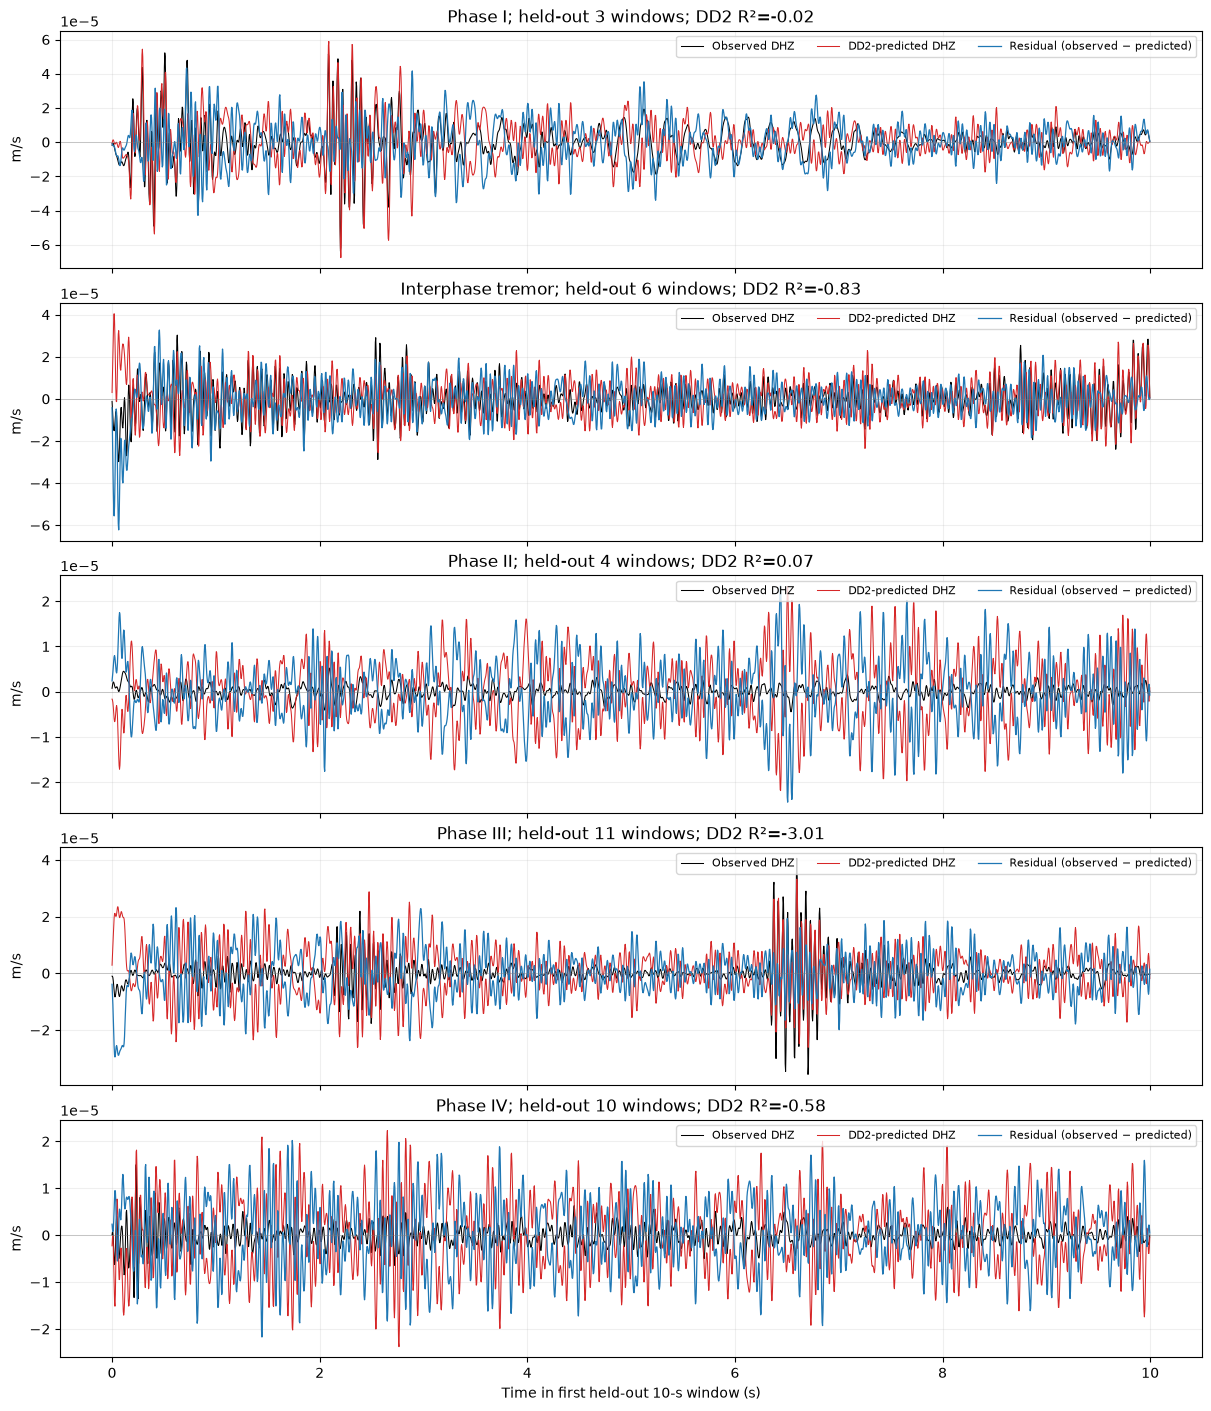

In [7]:
# Plot observed DHZ, DD2-only prediction, and the actual held-out residual.
# The blue residual contrasts with the black observation and red prediction.
fig, axes = plt.subplots(len(EVENT_LABELS), 1,
                         figsize=(12, 2.8 * len(EVENT_LABELS)),
                         sharex=True, constrained_layout=True)
if len(EVENT_LABELS) == 1:
    axes = [axes]
for ax, label in zip(axes, EVENT_LABELS):
    key = ("DD2", label)
    if key not in results:
        ax.set_visible(False)
        continue
    f, H, coh, obs, pred, resid, metrics = results[key]
    t = np.arange(obs.shape[1]) / fs
    ax.plot(t, obs[0], color="black", lw=0.75, label="Observed DHZ")
    ax.plot(t, pred[0], color="tab:red", lw=0.75, label="DD2-predicted DHZ")
    ax.plot(t, resid[0], color="tab:blue", lw=0.9, label="Residual (observed − predicted)")
    ax.axhline(0.0, color="0.5", lw=0.45, alpha=0.6)
    ax.set_ylabel("m/s")
    ax.set_title(f"{label}; held-out {metrics['heldout_window_count']} windows; DD2 R²={metrics['heldout_variance_explained']:.2f}")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("Time in first held-out 10-s window (s)")
fig.savefig(OUTDIR / "experimental_heldout_dd2_residuals_by_phase.png", dpi=180)
plt.show()


## Complex transfer phase and coherence

The DD2 transfer is complex, so its phase can vary with frequency. This plot shows the wrapped phase and training coherence after the geometry-based DHZ advance. It is a diagnostic of the pooled training estimate; held-out waveform skill remains the test of predictive value.


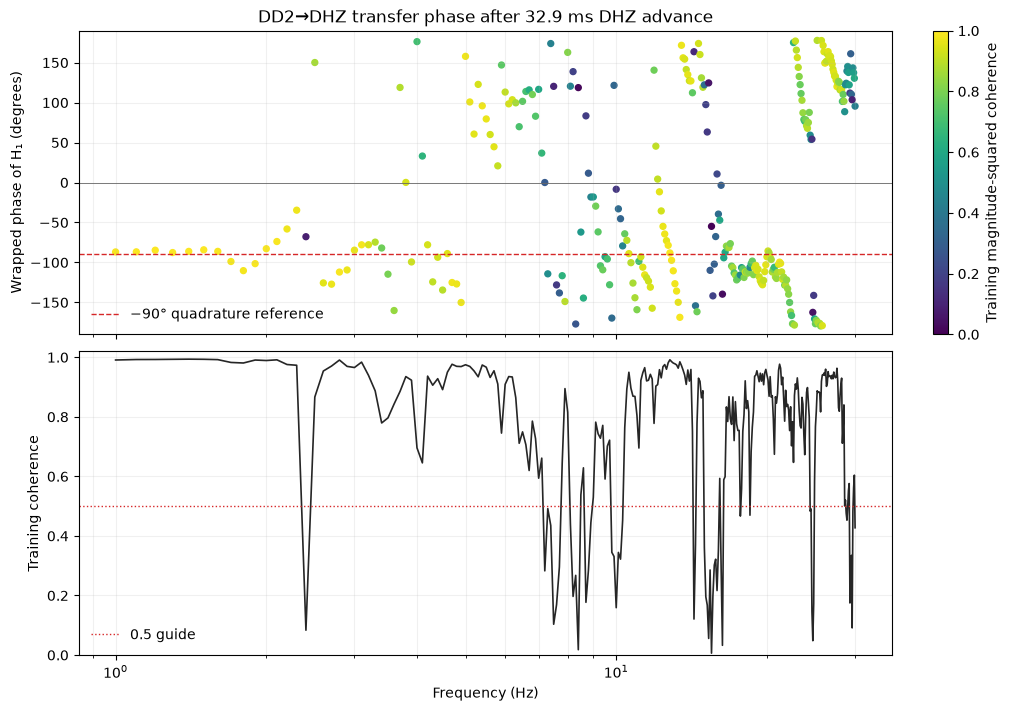

In [8]:
# Display the complex DD2 H1 transfer rather than magnitude alone.
dd2_h = transfer_table.loc[transfer_table["input"].eq("DD2")].sort_values("frequency_hz")
fig, (ax_phase, ax_coh) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                        constrained_layout=True)
sc = ax_phase.scatter(dd2_h["frequency_hz"], dd2_h["H_phase_deg"],
                      c=dd2_h["training_coherence"], cmap="viridis",
                      vmin=0, vmax=1, s=18)
ax_phase.axhline(-90, color="tab:red", ls="--", lw=1,
                 label="−90° quadrature reference")
ax_phase.axhline(0, color="0.4", lw=0.6)
ax_phase.set_xscale("log")
ax_phase.set_ylim(-190, 190)
ax_phase.set_ylabel("Wrapped phase of H₁ (degrees)")
ax_phase.set_title(f"DD2→DHZ transfer phase after {DHZ_ADVANCE_S * 1000:.1f} ms DHZ advance")
ax_phase.grid(True, which="both", alpha=0.18)
ax_phase.legend(frameon=False, loc="lower left")
fig.colorbar(sc, ax=ax_phase, label="Training magnitude-squared coherence")
ax_coh.plot(dd2_h["frequency_hz"], dd2_h["training_coherence"],
            color="0.15", lw=1.2)
ax_coh.axhline(0.5, color="tab:red", ls=":", lw=1, label="0.5 guide")
ax_coh.set_xscale("log")
ax_coh.set_ylim(0, 1.02)
ax_coh.set_xlabel("Frequency (Hz)")
ax_coh.set_ylabel("Training coherence")
ax_coh.grid(True, which="both", alpha=0.18)
ax_coh.legend(frameon=False)
fig.savefig(OUTDIR / "experimental_dd2_transfer_phase_coherence.png", dpi=180)
plt.show()


## Response of the SLC-40-steered three-microphone beam

Unlike the reference zero-delay array maps below, this response includes the DD1/DD3-to-DD2 steering delays used when forming `P["beam"]`. The heatmap fixes apparent speed at 351 m/s and shows response versus back azimuth and frequency; the expected SLC-40 direction is marked. A separate polar view shows selected-frequency sidelobes. This is a geometry-based beam response, not a measured noise spectrum.


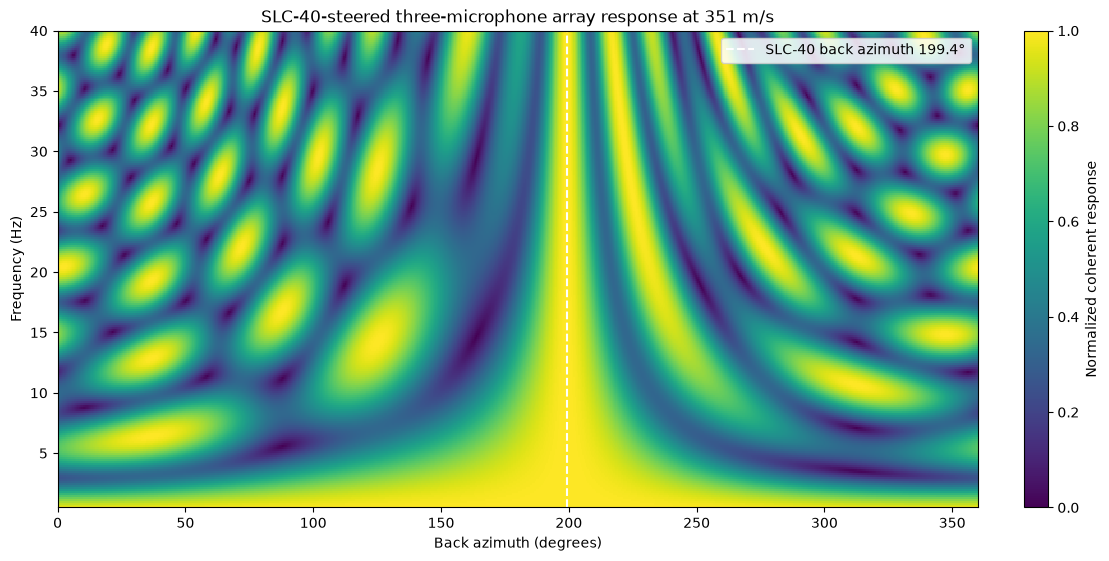

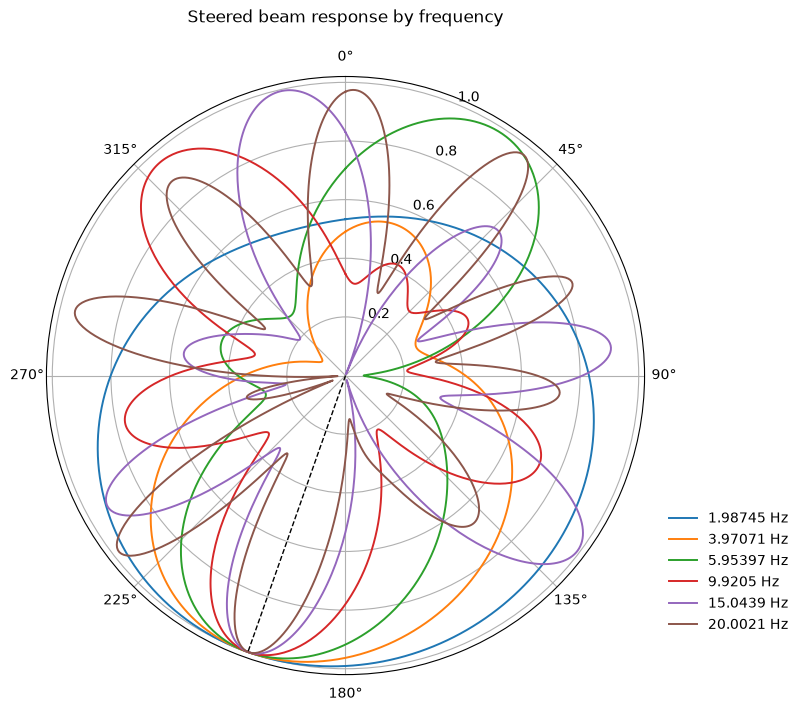

In [9]:
# Reproduce the response of the actual SLC-40-steered pressure beam.
# The input beam applies per-sensor delays from the surveyed SLC-40 ranges.
ARRAY_RESPONSE_SPEED_MPS = 351.0
beam_xy = GEOMETRY.loc[GEOMETRY.channel.isin(pressure_channels)].set_index("channel")
xy_abs = beam_xy.loc[pressure_channels, ["easting_m", "northing_m"]].to_numpy(float)
xy_ref = beam_xy.loc["DD2", ["easting_m", "northing_m"]].to_numpy(float)
xy_rel = xy_abs - xy_ref
steer_delays = np.array([
    (float(beam_xy.loc[ch, "distance_m"]) - ref_dist) / ARRAY_ALIGNMENT_SPEED_MPS
    for ch in pressure_channels
])
source_backaz = float(ANALYSIS_CONFIG["array_reference"]["back_azimuth_to_slc40_deg"])
backaz_grid = np.linspace(0.0, 360.0, 721)
freq_grid = np.linspace(0.5, 40.0, 240)
steered_response = np.empty((len(freq_grid), len(backaz_grid)))
for ia, baz in enumerate(backaz_grid):
    propagation_az = np.deg2rad((baz + 180.0) % 360.0)
    unit_e, unit_n = np.sin(propagation_az), np.cos(propagation_az)
    candidate_delays = (xy_rel[:, 0] * unit_e + xy_rel[:, 1] * unit_n) / ARRAY_RESPONSE_SPEED_MPS
    for jf, freq in enumerate(freq_grid):
        phase_residual = candidate_delays - steer_delays
        steered_response[jf, ia] = abs(np.mean(np.exp(-2j * np.pi * freq * phase_residual)))

fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
mesh = ax.pcolormesh(backaz_grid, freq_grid, steered_response, shading="auto",
                     vmin=0, vmax=1, cmap="viridis")
ax.axvline(source_backaz, color="white", ls="--", lw=1.5,
           label=f"SLC-40 back azimuth {source_backaz:.1f}°")
ax.set(xlim=(0, 360), ylim=(0.5, 40), xlabel="Back azimuth (degrees)",
       ylabel="Frequency (Hz)", title="SLC-40-steered three-microphone array response at 351 m/s")
ax.legend(loc="upper right", framealpha=0.85)
fig.colorbar(mesh, ax=ax, label="Normalized coherent response")
fig.savefig(OUTDIR / "experimental_steered_array_response_frequency_azimuth.png", dpi=180)
plt.show()

# Selected-frequency directivity curves show the main lobe and sidelobes more clearly.
fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
theta = np.deg2rad(backaz_grid)
for freq in [2.0, 4.0, 6.0, 10.0, 15.0, 20.0]:
    jj = int(np.argmin(np.abs(freq_grid - freq)))
    ax.plot(theta, steered_response[jj], lw=1.4, label=f"{freq_grid[jj]:g} Hz")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_ylim(0, 1.02)
ax.plot([np.deg2rad(source_backaz)] * 2, [0, 1], color="black", ls="--", lw=1)
ax.set_title("Steered beam response by frequency", pad=20)
ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.05), frameon=False)
fig.savefig(OUTDIR / "experimental_steered_array_response_polar.png", dpi=180)
plt.show()


## Measured background pressure reduction from array averaging

Compare the SLC-40-aligned three-sensor beam with DD2 in the 18 pre-event windows and in the remaining quiet-gap/post-event windows. Median 10-second spectra reduce sensitivity to occasional transients. A −4.77 dB line is the ideal beam/DD2 power ratio for three equal, independent sensor-noise sources; the observed ratio is data-driven and may be above or below that benchmark.


,noise_group,window_count,band_low_hz,band_high_hz,median_beam_to_DD2_power_ratio_db
0,Pre-event baseline,18,1.0,3.0,13.316213
1,Pre-event baseline,18,3.5,5.5,10.563129
2,Pre-event baseline,18,5.0,10.0,8.986296
3,Pre-event baseline,18,10.0,15.0,6.445570
4,Pre-event baseline,18,15.0,25.0,3.974597
5,Pre-event baseline,18,25.0,40.0,1.175202
6,Other quiet gaps/post-event,72,1.0,3.0,12.888910
7,Other quiet gaps/post-event,72,3.5,5.5,10.990930
8,Other quiet gaps/post-event,72,5.0,10.0,9.314098
9,Other quiet gaps/post-event,72,10.0,15.0,6.190206


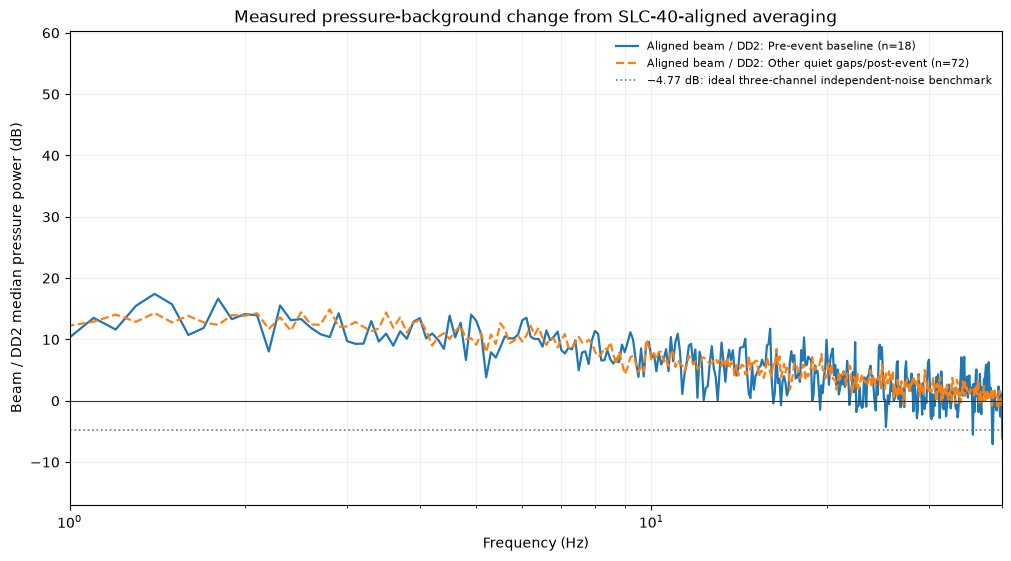

In [10]:
# Measure, rather than infer from aperture alone, the background change from averaging.
quiet_groups = {
    "Pre-event baseline": (GROUP_KINDS == "quiet") & (GROUP_LABELS == "pre-event noise"),
    "Other quiet gaps/post-event": (GROUP_KINDS == "quiet") & (GROUP_LABELS != "pre-event noise"),
}
noise_spectra = {}
noise_spectral_rows = []
noise_summary_rows = []
for group_name, mask in quiet_groups.items():
    count = int(mask.sum())
    if count == 0:
        continue
    for input_name in ["DD1", "DD2", "DD3", "beam"]:
        x = detrend_rows(P[input_name][mask])
        nf, powers = welch(x, fs=fs, nperseg=x.shape[1], axis=1,
                           scaling="density", detrend=False)
        median_psd = np.nanmedian(powers, axis=0)
        noise_spectra[(group_name, input_name)] = median_psd
        for freq, psd in zip(nf, median_psd):
            noise_spectral_rows.append({"noise_group": group_name, "input": input_name,
                                        "window_count": count, "frequency_hz": float(freq),
                                        "median_pressure_psd_pa2_per_hz": float(psd)})
    beam_db = 10.0 * np.log10(np.maximum(noise_spectra[(group_name, "beam")], np.finfo(float).tiny)
                              / np.maximum(noise_spectra[(group_name, "DD2")], np.finfo(float).tiny))
    for low, high in [(1.0, 3.0), (3.5, 5.5), (5.0, 10.0), (10.0, 15.0), (15.0, 25.0), (25.0, 40.0)]:
        use = (nf >= low) & (nf < high)
        noise_summary_rows.append({"noise_group": group_name, "window_count": count,
                                   "band_low_hz": low, "band_high_hz": high,
                                   "median_beam_to_DD2_power_ratio_db": float(np.nanmedian(beam_db[use])) if use.any() else np.nan})

noise_spectra_table = pd.DataFrame(noise_spectral_rows)
noise_summary_table = pd.DataFrame(noise_summary_rows)
noise_spectra_table.to_csv(OUTDIR / "experimental_quiet_pressure_noise_spectra.csv", index=False)
noise_summary_table.to_csv(OUTDIR / "experimental_quiet_pressure_noise_band_summary.csv", index=False)
display(noise_summary_table)

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for group_name, color, style in [("Pre-event baseline", "tab:blue", "-"),
                                 ("Other quiet gaps/post-event", "tab:orange", "--")]:
    if (group_name, "beam") not in noise_spectra:
        continue
    ratio_db = 10.0 * np.log10(
        np.maximum(noise_spectra[(group_name, "beam")], np.finfo(float).tiny)
        / np.maximum(noise_spectra[(group_name, "DD2")], np.finfo(float).tiny)
    )
    n = int(quiet_groups[group_name].sum())
    ax.plot(nf[1:], ratio_db[1:], color=color, ls=style, lw=1.6,
            label=f"Aligned beam / DD2: {group_name} (n={n})")
ax.axhline(0, color="0.2", lw=0.8)
ax.axhline(-10.0 * np.log10(3.0), color="0.45", ls=":", lw=1.2,
           label="−4.77 dB: ideal three-channel independent-noise benchmark")
ax.set_xscale("log")
ax.set_xlim(1, 40)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Beam / DD2 median pressure power (dB)")
ax.set_title("Measured pressure-background change from SLC-40-aligned averaging")
ax.grid(True, which="both", alpha=0.18)
ax.legend(frameon=False, fontsize=8)
fig.savefig(OUTDIR / "experimental_quiet_beam_noise_reduction.png", dpi=180)
plt.show()


## Reference: unsteered BCHH array response

These original single-frequency maps show the zero-delay arithmetic mean, not the SLC-40-aligned beam. They are retained as a reference; the steered-response plots above match the delay-and-average operation used in the pressure beam.


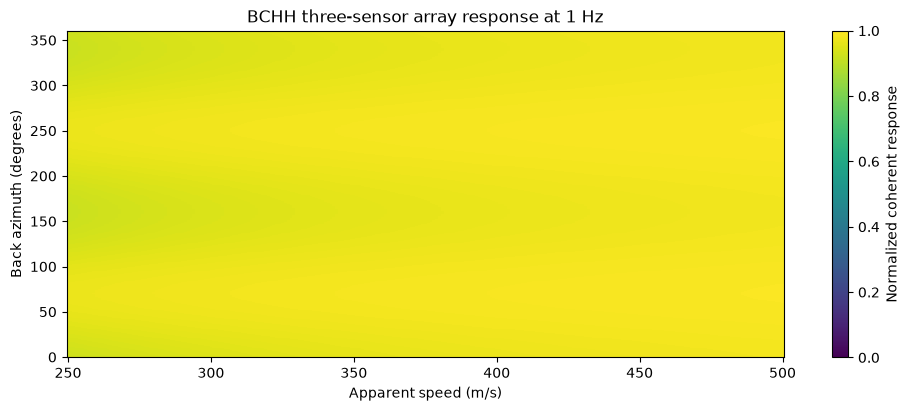

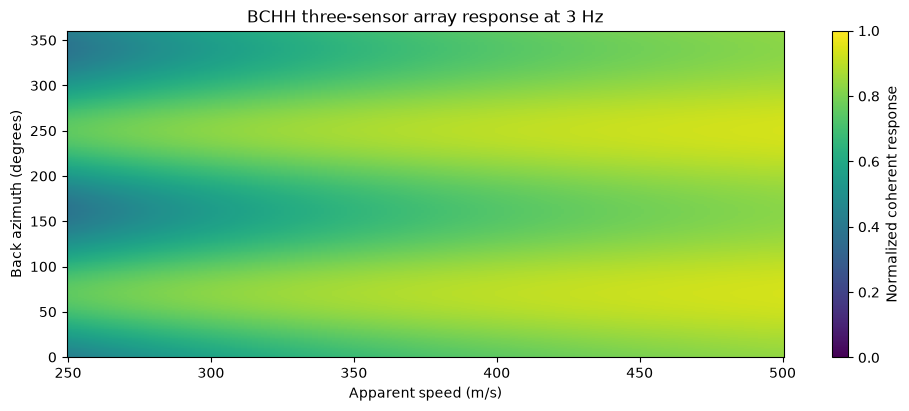

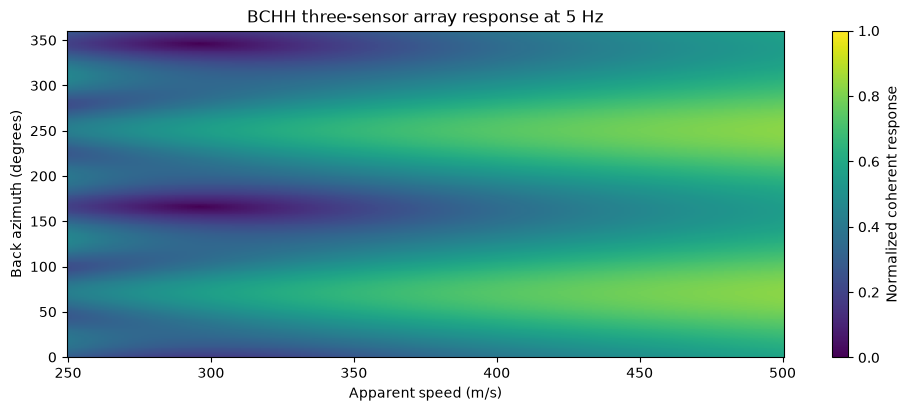

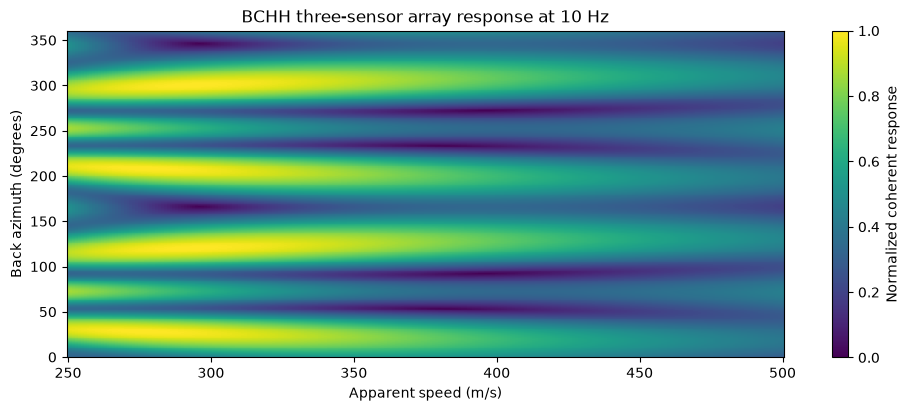

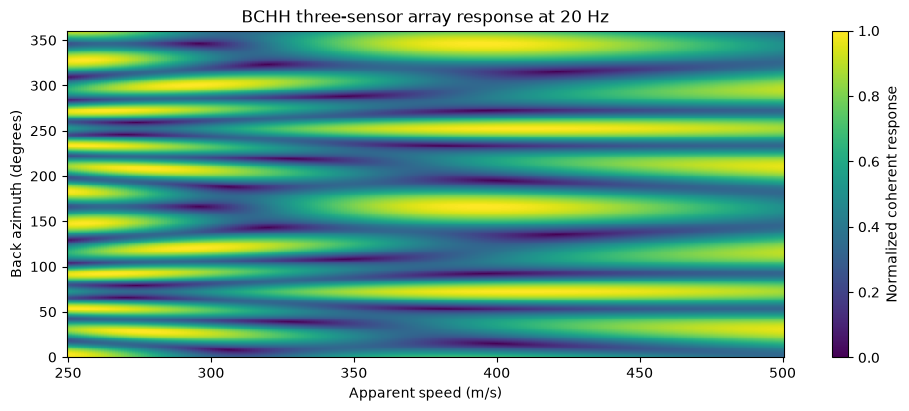

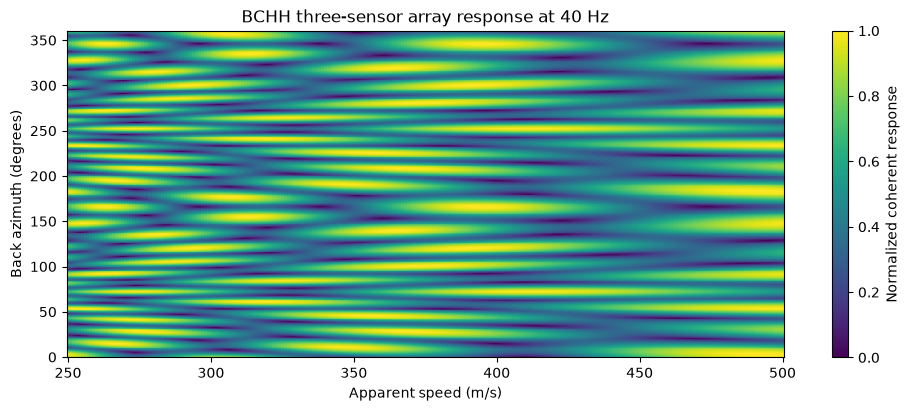

In [11]:
xy = coords.loc[pressure_channels, ["easting_m", "northing_m"]].to_numpy(float)
xy -= xy.mean(axis=0)
backaz = np.linspace(0, 360, 361)
speeds = np.linspace(250, 500, 251)
plot_freqs = [1.0, 3.0, 5.0, 10.0, 20.0, 40.0]
response_rows=[]
for freq in plot_freqs:
    grid=np.empty((len(backaz),len(speeds)))
    for ia,baz in enumerate(backaz):
        prop=np.deg2rad((baz+180.0)%360.0)
        se=np.sin(prop);sn=np.cos(prop)
        for ic,c in enumerate(speeds):
            tau=(xy[:,0]*se+xy[:,1]*sn)/c
            grid[ia,ic]=abs(np.mean(np.exp(-2j*np.pi*freq*tau)))
            response_rows.append({"frequency_hz":freq,"back_azimuth_deg":baz,"apparent_speed_mps":c,"normalized_array_response":grid[ia,ic]})
    fig,ax=plt.subplots(figsize=(9,4),constrained_layout=True)
    mesh=ax.pcolormesh(speeds,backaz,grid,shading="auto",vmin=0,vmax=1,cmap="viridis")
    fig.colorbar(mesh,ax=ax,label="Normalized coherent response")
    ax.set(xlabel="Apparent speed (m/s)",ylabel="Back azimuth (degrees)",title=f"BCHH three-sensor array response at {freq:g} Hz")
    fig.savefig(OUTDIR/f"array_response_{freq:g}Hz.png",dpi=160);plt.show()
pd.DataFrame(response_rows).to_csv(OUTDIR/"experimental_array_response.csv",index=False)


## Reading the results

- DHZ is advanced by the geometry-based SLC-40 delay before transfer fitting and scoring. The estimated transfer phase remains part of the model; it is not forced to 90 degrees.
- Compare the held-out transfer scores across Phase I, the interphase tremor, and Phases II–IV; differences can indicate changing coupling or nonstationarity. The pre-event and quiet-gap scores show how much apparent prediction occurs without the modeled event phases.
- DD2 versus beam differences show whether the result depends on a single sensor or spatial averaging.
- A small residual does **not** prove that the removed motion was all air-to-ground coupling; pressure and direct seismic arrivals can correlate because of common source timing.
- The residual is direct seismic energy plus unrelated noise, coupling-model error, and any signal not predictable from the selected pressure input. It is an upper bound on unexplained energy, not an estimate of direct seismic energy alone.
- The conditional predicted/residual mean-square ratio is reported separately by event phase and quiet interval only as a model-dependent decomposition. It is not a source-energy ratio or a calibrated ground-coupled/direct energy partition.
- Array-response lobes show geometrical ambiguity. Temporal sampling and interpolation add uncertainty to delays; the numerical search-grid step is not measurement precision.

Before promoting a result, repeat blocked validation on several separated intervals, compare DD2 and beam inputs, test reasonable alignment speeds and bands, inspect instrument response / polarity / units, and verify that inferred phase is stable. Only then consider updating production Notebook 070 or manuscript language.


In [12]:
print("Experimental outputs:", OUTDIR)
print("Input stream:", STREAM_PATH)
print("No production files were modified by this notebook.")


Experimental outputs: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/155_experimental_pressure_dhz_array
Input stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/bchh_corrected_analysis_window.pkl
No production files were modified by this notebook.
